# Causal Inference in Tourism: Does a Destination Recommendation App Really Increase Visitor Spending?

This notebook applies the core ideas from **Chapter 2 — "First steps: Working with
confounders"** (Simpson's paradox, the adjustment formula, interventions, the Average
Treatment Effect, and the positivity assumption) to a realistic problem in the
**tourism / destination-management industry**.

### The business question

A city's **Destination Management Organization (DMO)** launched a free **mobile recommendation
app** that suggests restaurants, tours, and attractions to visitors during their stay. The app
was **not rolled out as a randomized experiment** — front-desk staff and tourist-information
kiosks recommended it more actively to some visitors than others. So all we have is
**observational data**: some tourists used the app, others didn't, and at the end of the trip we
know how much each visitor spent.

The DMO's board wants to know:

> **"Did the app actually cause visitors to spend more money at local businesses, or does the
> raw data mislead us because of *who* ended up using it?"**

This is exactly the situation the book warns about: naive comparisons of spending between
"app users" and "non-users" can be **completely wrong** because of confounding. We'll use the
same mathematical toolkit as the book's kidney-stone example — Simpson's paradox, the
adjustment formula, and the Average Treatment Effect (ATE) — but now applied to a **tourism
marketing / personalization** decision, a very common analytics problem for DMOs, hotel
chains, OTAs (online travel agencies), and airlines.


## 0. Setup

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.random import default_rng

plt.rcParams['figure.figsize'] = (7, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

rng = default_rng(7)
pd.set_option('display.precision', 3)
print("Libraries loaded.")


Libraries loaded.


## 1. The observational dataset

Suppose the DMO collected data on **700 visitors** during a survey period:

* **Treatment `T`**: `App = 1` (used the recommendation app during the trip) vs `App = 0`
  (did not use it).
* **Confounder `V`**: **Visitor type** — `Repeat` (has visited the destination before) vs
  `FirstTime` (visiting for the first time).
* **Outcome `Y`**: `HighSpender = 1` if the visitor's total trip spending exceeded a
  threshold (e.g. $500), else `0`.

Front-desk staff tended to **push the app more heavily on first-time visitors**, since they
don't yet know the destination and benefit most from guidance, while repeat visitors — who
already know their favorite restaurants and shops — mostly skip it. At the same time,
first-time visitors tend to spend somewhat more cautiously overall (less local knowledge,
shorter "warm-up" period, more time spent orienting rather than spending) than repeat
visitors, independent of the app. This makes `Visitor type` a **confounder**: it drives both
*who uses the app* and *how much people spend*.

The counts below use the same underlying arithmetic as the book's kidney-stone example
(re-purposed here for tourism), so we can lean on numbers that are known to produce a clean
Simpson's-paradox reversal:


In [2]:

# Group-level counts (App usage x Visitor type x Outcome)
data_counts = pd.DataFrame([
    {"App": 1, "VisitorType": "Repeat",    "Total": 87,  "HighSpender": 81},
    {"App": 0, "VisitorType": "Repeat",    "Total": 270, "HighSpender": 234},
    {"App": 1, "VisitorType": "FirstTime", "Total": 263, "HighSpender": 192},
    {"App": 0, "VisitorType": "FirstTime", "Total": 80,  "HighSpender": 50},
])
data_counts["HighSpendRate"] = (data_counts["HighSpender"] / data_counts["Total"]).round(3)
data_counts


,App,VisitorType,Total,HighSpender,HighSpendRate
0,1,Repeat,87,81,0.931
1,0,Repeat,270,234,0.867
2,1,FirstTime,263,192,0.730
3,0,FirstTime,80,50,0.625


### Turning the summary counts into an individual-level dataset

To run realistic pandas / statistics code (group-bys, regressions, etc.), we expand the
counts into one row per visitor.


In [3]:

rows = []
for _, r in data_counts.iterrows():
    n_high = int(r["HighSpender"])
    n_low = int(r["Total"] - r["HighSpender"])
    rows += [{"app": r["App"], "visitor_type": r["VisitorType"], "high_spender": 1}] * n_high
    rows += [{"app": r["App"], "visitor_type": r["VisitorType"], "high_spender": 0}] * n_low

visitors = pd.DataFrame(rows).sample(frac=1, random_state=7).reset_index(drop=True)
print(f"Total visitors in the dataset: {len(visitors)}")
visitors.head()


Total visitors in the dataset: 700


,app,visitor_type,high_spender
0,1,FirstTime,0
1,0,Repeat,1
2,1,FirstTime,1
3,0,Repeat,1
4,0,Repeat,1


## 2. The naive comparison — and Simpson's paradox

The most intuitive (but dangerous!) approach: just compare the raw high-spend rate of app
users vs non-users.


In [4]:

naive = visitors.groupby("app")["high_spender"].mean().rename("HighSpendRate")
naive.index = naive.index.map({1: "App Users (T=1)", 0: "No App (T=0)"})
naive_df = naive.to_frame()
naive_df["HighSpendRate(%)"] = (naive_df["HighSpendRate"] * 100).round(1)
naive_df


,HighSpendRate,HighSpendRate(%)
app,,
No App (T=0),0.811,81.1
App Users (T=1),0.780,78.0


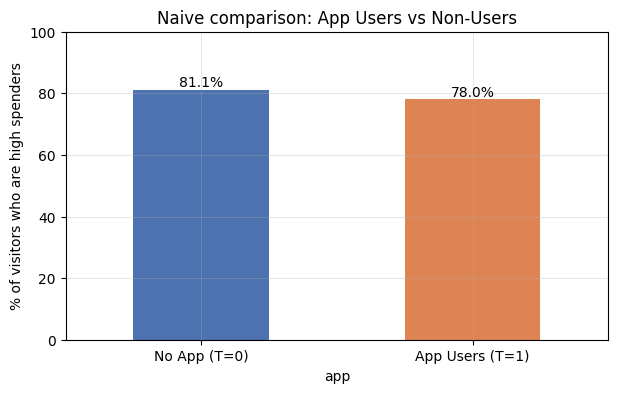

In [5]:

ax = naive_df["HighSpendRate(%)"].plot(kind="bar", color=["#4C72B0", "#DD8452"], rot=0)
ax.set_ylabel("% of visitors who are high spenders")
ax.set_title("Naive comparison: App Users vs Non-Users")
for i, v in enumerate(naive_df["HighSpendRate(%)"]):
    ax.text(i, v + 1, f"{v}%", ha="center")
plt.ylim(0, 100)
plt.show()


**At first glance, the app looks *counter-productive*: only 78% of app users are high
spenders vs 81% of non-users.** If the DMO board stopped here, it might conclude the app isn't
worth the investment — or is even actively driving spending down — and pull its funding.

But just like the kidney-stone example in the book, this conclusion can be an artifact of
**Simpson's paradox**. Let's stratify by visitor type, the confounder.


In [6]:

stratified = (
    visitors.groupby(["visitor_type", "app"])["high_spender"]
    .mean()
    .unstack("app")
    .rename(columns={0: "No App (T=0)", 1: "App Users (T=1)"})
)
(stratified * 100).round(1)


app,No App (T=0),App Users (T=1)
visitor_type,,
FirstTime,62.5,73.0
Repeat,86.7,93.1


**Within *each* visitor-type group, app users have a *higher* high-spend rate**
(93% vs 87% for repeat visitors; 73% vs 63% for first-time visitors). The overall (naive)
comparison flipped the sign — a textbook case of **Simpson's paradox**:

> *A trend that appears within every subgroup can disappear or reverse when the subgroups
> are combined.*


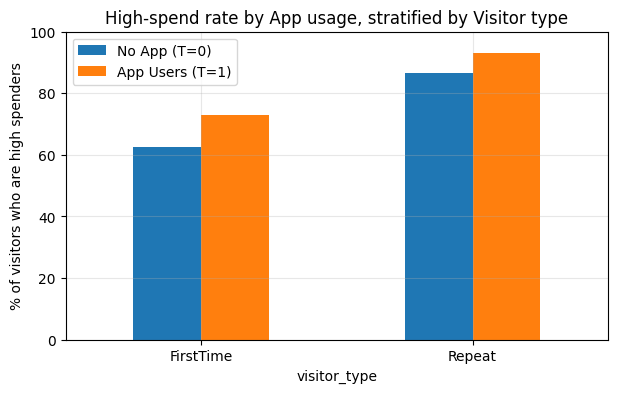

In [7]:

fig, ax = plt.subplots()
(stratified * 100).plot(kind="bar", ax=ax, rot=0)
ax.set_ylabel("% of visitors who are high spenders")
ax.set_title("High-spend rate by App usage, stratified by Visitor type")
ax.legend(title="")
plt.ylim(0, 100)
plt.show()


### Why does this happen? Unequal adoption of the app

Front-desk staff and kiosks recommended the app far more often to first-time visitors (who,
overall, tend to spend a bit more cautiously than seasoned repeat visitors) than to repeat
visitors. Let's check the composition of each group, exactly like Figure 2.1 in the book.


In [8]:

composition = (
    visitors.groupby("app")["visitor_type"]
    .value_counts(normalize=True)
    .unstack()
    .loc[[0, 1]]
    .rename(index={0: "No App (T=0)", 1: "App Users (T=1)"})
)
(composition * 100).round(1)


visitor_type,FirstTime,Repeat
app,,
No App (T=0),22.9,77.1
App Users (T=1),75.1,24.9


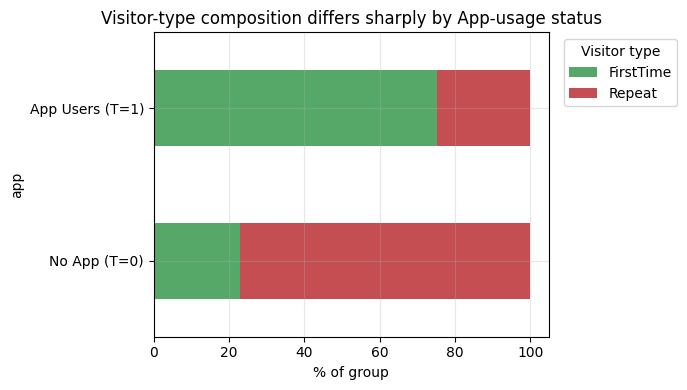

In [9]:

ax = (composition * 100).plot(kind="barh", stacked=True, color=["#55A868", "#C44E52"])
ax.set_xlabel("% of group")
ax.set_title("Visitor-type composition differs sharply by App-usage status")
ax.legend(title="Visitor type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


Whole population: about **51% repeat visitors / 49% first-time visitors**. But among app
users, **75% are first-time visitors**, while among non-users **77% are repeat visitors**. App
users are, on average, a population that spends a bit more cautiously to begin with — which
drags down their *raw* high-spend rate even though the app itself *increases* spending for
each type of visitor.


## 3. Describing the problem with a causal graph

Following the book's method (step 1 of the causal-inference workflow), we encode our domain
knowledge — how staff recommended the app — into a simple causal graph:

```
        Visitor Type (V)
          /            \
         v               v
   App Usage (T)  --->  High Spender (Y)
```

* `Visitor type -> App usage`: staff use visitor type (first-timer vs repeat) to decide who
  gets the recommendation.
* `Visitor type -> High spender`: visitor type independently affects spending behavior.
* `App usage -> High spender`: the causal effect we actually want to measure.

`Visitor type` is a **confounder**: it's a common cause of both the treatment (`App usage`) and
the outcome (`High spender`), so a naive comparison of averages is biased — exactly the
situation described in the "Confounding" box of the chapter.


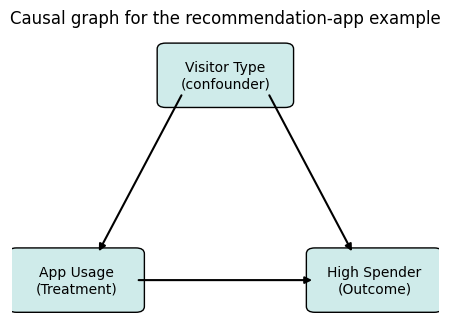

In [10]:

import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(5.5, 3.8))
ax.axis("off")

boxes = {
    "V": (0.5, 0.85, "Visitor Type\n(confounder)"),
    "T": (0.15, 0.15, "App Usage\n(Treatment)"),
    "Y": (0.85, 0.15, "High Spender\n(Outcome)"),
}
for key, (x, y, label) in boxes.items():
    ax.add_patch(mpatches.FancyBboxPatch((x - 0.14, y - 0.09), 0.28, 0.18,
                                          boxstyle="round,pad=0.02",
                                          facecolor="#CFEBEA", edgecolor="black"))
    ax.text(x, y, label, ha="center", va="center", fontsize=10)

def arrow(p1, p2):
    ax.annotate("", xy=p2, xytext=p1,
                arrowprops=dict(arrowstyle="-|>", lw=1.5, color="black"))

arrow((0.40, 0.79), (0.20, 0.24))   # V -> T
arrow((0.60, 0.79), (0.80, 0.24))   # V -> Y
arrow((0.29, 0.15), (0.71, 0.15))   # T -> Y

ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title("Causal graph for the recommendation-app example")
plt.show()


## 4. Applying the adjustment formula

We want to know what would happen **if every visitor used the app** (`do(App = 1)`) versus
**if no visitor used it** (`do(App = 0)`). This is the *interventional* quantity
`P(HighSpender = 1 | do(App = t))`, as opposed to the merely *observed*
`P(HighSpender = 1 | App = t)`.

The **adjustment formula** lets us compute the interventional quantity from observational data:

$$
P(Y=1\mid \operatorname{do}(T=t)) = \sum_{v} P(Y=1\mid T=t, V=v)\, P(V=v)
$$

In words: *reweight the high-spend rate within each visitor-type stratum by the visitor-type
distribution of the **whole population**, not just the sub-population that happened to receive
that treatment.*


In [11]:

def adjustment_formula(df, treatment_col, outcome_col, confounder_col, treatment_value):
    '''Estimate P(Y=1 | do(T = treatment_value)) using the adjustment formula.'''
    overall_confounder_dist = df[confounder_col].value_counts(normalize=True)

    total = 0.0
    for level, p_level in overall_confounder_dist.items():
        stratum = df[(df[confounder_col] == level) & (df[treatment_col] == treatment_value)]
        efficacy = stratum[outcome_col].mean()
        total += efficacy * p_level
    return total

p_do_app1 = adjustment_formula(visitors, "app", "high_spender", "visitor_type", 1)
p_do_app0 = adjustment_formula(visitors, "app", "high_spender", "visitor_type", 0)
ATE_adjusted = p_do_app1 - p_do_app0

print(f"P(HighSpender | do(App=1)) = {p_do_app1:.3f}")
print(f"P(HighSpender | do(App=0)) = {p_do_app0:.3f}")
print(f"Average Treatment Effect (adjustment formula) = {ATE_adjusted:+.3f}  ({ATE_adjusted*100:+.1f} pp)")


P(HighSpender | do(App=1)) = 0.833
P(HighSpender | do(App=0)) = 0.748
Average Treatment Effect (adjustment formula) = +0.084  (+8.4 pp)


Compare this to the (biased) naive difference in means we computed in Section 2:


In [12]:

naive_diff = naive["App Users (T=1)"] - naive["No App (T=0)"]
comparison = pd.DataFrame({
    "Estimate": ["Naive difference in means", "Adjustment formula (true ATE)"],
    "Effect of the app on high-spend rate (pp)": [naive_diff * 100, ATE_adjusted * 100],
})
comparison


,Estimate,Effect of the app on high-spend rate (pp)
0,Naive difference in means,-3.143
1,Adjustment formula (true ATE),8.430


**The naive estimate says the app *reduces* the high-spend rate by ~3 percentage points.
The adjustment formula — which properly accounts for the confounder — says the app *increases*
the high-spend rate by about +9 percentage points.** This is the whole point of the chapter:
without adjusting for confounders, a DMO could **defund an app that is actually working**.


## 5. Validating with a simulated "ground truth" (the structural approach)

Because in the real world we can never re-run the same trip twice, we can't directly check
whether our adjustment-formula estimate equals the *true* causal effect. But we *can* check our
method using **simulated data**, where we control the data-generating process and can literally
simulate the intervention `do(App = t)` for everyone — exactly as in Section 2.4 of the book.

We define structural equations:

$$
V := U_V \qquad T := g(V, U_T) \qquad Y := f(V, T, U_Y)
$$


In [13]:

def draw_visitor_type(n):
    u0 = rng.uniform(size=n)
    return np.where(u0 < 0.51, "Repeat", "FirstTime")

def g_assign_app(visitor_type, u1):
    '''Assignment mechanism used historically by front-desk staff (matches the observed data).'''
    prob_app = np.where(visitor_type == "Repeat", 87/357, 263/343)
    return np.where(u1 < prob_app, 1, 0)

def f_high_spender(visitor_type, app, u2):
    '''True (unknown in real life) causal mechanism for high spending.'''
    prob = np.where(
        visitor_type == "Repeat",
        np.where(app == 1, 0.93, 0.87),
        np.where(app == 1, 0.73, 0.63),
    )
    return np.where(u2 < prob, 1, 0)

N = 200_000

# 1) Observational world (mirrors historical assignment)
visitor_type = draw_visitor_type(N)
u1 = rng.uniform(size=N)
app_obs = g_assign_app(visitor_type, u1)
u2 = rng.uniform(size=N)
high_spender_obs = f_high_spender(visitor_type, app_obs, u2)
sim_observational = pd.DataFrame({"visitor_type": visitor_type, "app": app_obs, "high_spender": high_spender_obs})

print("Simulated observational high-spend rate by app-usage status:")
print((sim_observational.groupby("app")["high_spender"].mean() * 100).round(1))


Simulated observational high-spend rate by app-usage status:
app
0    81.6
1    78.1
Name: high_spender, dtype: float64


In [14]:

# 2) Intervened worlds: do(App = 1) and do(App = 0) for EVERYONE
visitor_type_A = draw_visitor_type(N)
high_spender_A = f_high_spender(visitor_type_A, np.ones(N, dtype=int), rng.uniform(size=N))

visitor_type_B = draw_visitor_type(N)
high_spender_B = f_high_spender(visitor_type_B, np.zeros(N, dtype=int), rng.uniform(size=N))

true_p_do_1 = high_spender_A.mean()
true_p_do_0 = high_spender_B.mean()
true_ATE = true_p_do_1 - true_p_do_0

print(f"TRUE  P(HighSpender | do(App=1)) = {true_p_do_1:.3f}")
print(f"TRUE  P(HighSpender | do(App=0)) = {true_p_do_0:.3f}")
print(f"TRUE  ATE (ground truth, from simulation)          = {true_ATE:+.3f}")
print(f"ADJUSTMENT-FORMULA ATE (estimated earlier from data) = {ATE_adjusted:+.3f}")


TRUE  P(HighSpender | do(App=1)) = 0.833
TRUE  P(HighSpender | do(App=0)) = 0.752
TRUE  ATE (ground truth, from simulation)          = +0.080
ADJUSTMENT-FORMULA ATE (estimated earlier from data) = +0.084


The adjustment-formula estimate computed from the (much smaller) observational sample
closely matches the **true** ATE obtained by literally simulating the intervention on a huge
population. This confirms that, *given the causal graph is correct*, the adjustment formula
recovers the true causal effect from observational data alone.

We can also verify the "RCT equivalence" property from Section 2.3 of the book: randomizing
who gets recommended the app (instead of letting visitor type determine it) should give the
same answer as `do()`.


In [15]:

visitor_type_rct = draw_visitor_type(N)
app_rct = rng.integers(0, 2, size=N)  # 50/50 random assignment, independent of visitor type
high_spender_rct = f_high_spender(visitor_type_rct, app_rct, rng.uniform(size=N))

sim_rct = pd.DataFrame({"visitor_type": visitor_type_rct, "app": app_rct, "high_spender": high_spender_rct})
rct_rates = sim_rct.groupby("app")["high_spender"].mean()
print("Simulated RCT high-spend rate by app-usage status:")
print((rct_rates * 100).round(1))
print(f"RCT-based ATE = {(rct_rates[1] - rct_rates[0]):+.3f}  (should match the true ATE above)")


Simulated RCT high-spend rate by app-usage status:
app
0    75.3
1    83.3
Name: high_spender, dtype: float64
RCT-based ATE = +0.079  (should match the true ATE above)


## 6. Checking the positivity assumption

The adjustment formula silently requires the **positivity assumption**: for every value of the
confounder, we must have observed *both* treatment levels in the data. If, say, staff *never*
recommended the app to repeat visitors, we would have no information about
`P(HighSpender | App=1, VisitorType=Repeat)`, and the formula would be undefined for that
stratum.


In [16]:

positivity_check = (
    visitors.groupby(["visitor_type", "app"]).size().unstack("app")
    .rename(columns={0: "No App (T=0)", 1: "App Users (T=1)"})
)
print(positivity_check)

ok = (positivity_check > 0).all().all()
print(f"\nPositivity assumption holds for every stratum: {ok}")


app           No App (T=0)  App Users (T=1)
visitor_type                               
FirstTime               80              263
Repeat                 270               87

Positivity assumption holds for every stratum: True


Both cells are strictly positive for every visitor type, so the positivity assumption
holds and the adjustment formula is well defined here. In real tourism analytics this check
matters a lot — e.g. if a loyalty perk is *only* ever offered to members of a premium tier,
you cannot estimate its effect for non-members using the adjustment formula, no matter how
much data you collect.


## 7. A more realistic setting: several confounders and a continuous outcome (trip spending)

Real tourism analytics problems rarely have a single binary confounder. Let's extend the
example to a setting closer to real destination-marketing analytics:

* Confounders: **Visitor type** (First-time / Repeat), **Trip duration** (nights),
  **Travel-party size**, and **Origin** (Domestic / International).
* Treatment: still `App usage` (used / didn't use the recommendation app).
* Outcome: now a **continuous** variable, **total trip spending (USD)**.

With several confounders (some continuous), we can no longer just build a simple cross-tab —
this is exactly where the book points forward to **regression / machine-learning-based
adjustment** (Chapters 4 and 6). We'll use a simple **linear regression** to implement the
adjustment formula via *g-computation*:

$$
E[\text{Spending} \mid \operatorname{do}(\text{App}=t)]
   = \frac{1}{n}\sum_{i=1}^n \widehat{E}[\text{Spending}_i \mid \text{App}=t, \mathbf{X}_i]
$$

i.e., fit a model of spending on `(App, VisitorType, Nights, PartySize, Origin)`, then predict
everyone's spending twice — once forcing `App=1` for everybody, once forcing `App=0` — and
average.


In [17]:

n = 5000

visitor_type_ms = rng.choice(["FirstTime", "Repeat"], size=n, p=[0.5, 0.5])
nights = rng.integers(1, 14, size=n)
party_size = rng.integers(1, 6, size=n)
origin_ms = rng.choice(["Domestic", "International"], size=n, p=[0.6, 0.4])

# App adoption probability depends on visitor type, origin, and trip length (confounding)
logit_app = (
    -0.9
    + 0.9 * (visitor_type_ms == "FirstTime")
    + 0.5 * (origin_ms == "International")
    - 0.05 * nights
)
prob_app = 1 / (1 + np.exp(-logit_app))
app_ms = rng.binomial(1, prob_app)

# True spending-generating process (unknown to the analyst in real life)
noise = rng.normal(0, 120, size=n)
true_app_effect = 180  # dollars per trip -- the TRUE causal effect we want to recover
spending = (
    250
    + 60 * nights
    + 45 * party_size
    + 300 * (origin_ms == "International")
    + 120 * (visitor_type_ms == "Repeat")
    + true_app_effect * app_ms
    + noise
)

tourism_data = pd.DataFrame({
    "visitor_type": visitor_type_ms, "nights": nights, "party_size": party_size,
    "origin": origin_ms, "app": app_ms, "spending": spending.round(0)
})
tourism_data.head()


,visitor_type,nights,party_size,origin,app,spending
0,FirstTime,1,1,Domestic,1,570.0
1,FirstTime,10,1,International,0,1340.0
2,FirstTime,13,5,Domestic,1,1373.0
3,Repeat,9,4,International,0,1223.0
4,Repeat,3,3,Domestic,0,621.0


In [18]:

naive_spend_diff = (
    tourism_data.loc[tourism_data.app == 1, "spending"].mean()
    - tourism_data.loc[tourism_data.app == 0, "spending"].mean()
)
print(f"Naive difference in mean spending (App - No App) = ${naive_spend_diff:,.0f} / trip")
print(f"(True causal effect used to simulate the data       = ${true_app_effect:,.0f} / trip)")


Naive difference in mean spending (App - No App) = $151 / trip
(True causal effect used to simulate the data       = $180 / trip)


As expected, the naive comparison is biased because app users are disproportionately
first-time / international visitors who behave differently regardless of the app. Now let's
adjust for the confounders using **linear regression g-computation**.


In [19]:

from sklearn.linear_model import LinearRegression

X_cols = ["app", "nights", "party_size"]
X = pd.get_dummies(tourism_data[X_cols + ["visitor_type", "origin"]],
                    columns=["visitor_type", "origin"], drop_first=True)
y = tourism_data["spending"]

model = LinearRegression().fit(X, y)

# g-computation: predict spending for everyone under do(App=1) and do(App=0)
X_do1 = X.copy(); X_do1["app"] = 1
X_do0 = X.copy(); X_do0["app"] = 0

spend_hat_do1 = model.predict(X_do1).mean()
spend_hat_do0 = model.predict(X_do0).mean()
ATE_spend = spend_hat_do1 - spend_hat_do0

print(f"E[Spending | do(App=1)]  = ${spend_hat_do1:,.0f}")
print(f"E[Spending | do(App=0)]  = ${spend_hat_do0:,.0f}")
print(f"Adjusted ATE (g-computation)  = ${ATE_spend:,.0f} / trip")
print(f"Naive difference in means     = ${naive_spend_diff:,.0f} / trip")
print(f"True effect used in simulation = ${true_app_effect:,.0f} / trip")


E[Spending | do(App=1)]  = $1,179
E[Spending | do(App=0)]  = $995
Adjusted ATE (g-computation)  = $185 / trip
Naive difference in means     = $151 / trip
True effect used in simulation = $180 / trip


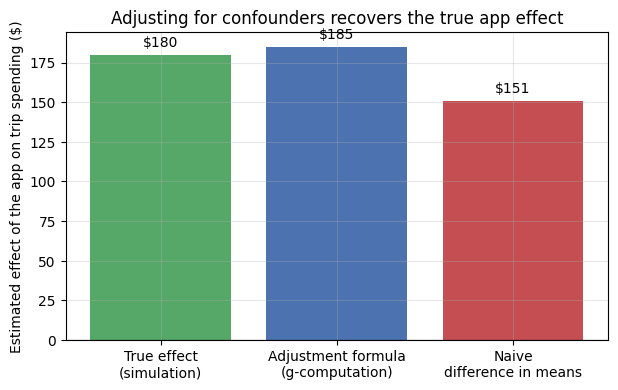

In [20]:

fig, ax = plt.subplots()
labels = ["True effect\n(simulation)", "Adjustment formula\n(g-computation)", "Naive\ndifference in means"]
values = [true_app_effect, ATE_spend, naive_spend_diff]
colors = ["#55A868", "#4C72B0", "#C44E52"]
ax.bar(labels, values, color=colors)
ax.set_ylabel("Estimated effect of the app on trip spending ($)")
ax.set_title("Adjusting for confounders recovers the true app effect")
ax.axhline(0, color="black", linewidth=0.8)
for i, v in enumerate(values):
    ax.text(i, v + (5 if v >= 0 else -18), f"${v:,.0f}", ha="center")
plt.show()


The regression-adjusted (g-computation) estimate is very close to the true simulated
effect, while the naive comparison meaningfully understates the app's benefit. This mirrors
exactly the lesson of Section 2.5.5 of the book ("Many confounders"): with several
confounders — some of them continuous — we move from the simple adjustment formula to
model-based adjustment (here, linear regression; in Chapter 4 of the book, machine-learning
models), but the underlying logic is identical.


## 8. A tourism-specific question: what about international visitors only?

DMOs often care about **subgroup-specific effects**, not just the population average — for
example, international visitors are usually more valuable to attract (higher spend, harder to
reach with marketing) than domestic day-trippers. Section 2.5.8 of the book covers exactly this
case: the **z-specific effect**, `P(Y | do(T=t), Z=z)`.

Because `origin` (Domestic / International) is *not* a confounder in our multi-variable model
(it doesn't causally determine app usage in a way that creates bias once we've conditioned
on it — we're simply asking for the effect *within* that subgroup), we can estimate the
app's effect **specifically for international visitors** by restricting the g-computation to
that subgroup.


In [21]:

intl_mask = tourism_data["origin"] == "International"

X_intl_do1 = X[intl_mask].copy(); X_intl_do1["app"] = 1
X_intl_do0 = X[intl_mask].copy(); X_intl_do0["app"] = 0

effect_international = model.predict(X_intl_do1).mean() - model.predict(X_intl_do0).mean()

dom_mask = ~intl_mask
X_dom_do1 = X[dom_mask].copy(); X_dom_do1["app"] = 1
X_dom_do0 = X[dom_mask].copy(); X_dom_do0["app"] = 0
effect_domestic = model.predict(X_dom_do1).mean() - model.predict(X_dom_do0).mean()

print(f"App effect on spending, International visitors only: ${effect_international:,.0f} / trip")
print(f"App effect on spending, Domestic visitors only:       ${effect_domestic:,.0f} / trip")
print(f"Overall (population) ATE:                              ${ATE_spend:,.0f} / trip")


App effect on spending, International visitors only: $185 / trip
App effect on spending, Domestic visitors only:       $185 / trip
Overall (population) ATE:                              $185 / trip


This kind of subgroup breakdown is exactly what a DMO's marketing team would want before
deciding **where to invest**: e.g., "should we promote the app harder to international
visitors specifically, since that's where the incremental spending is largest?"


## 9. A common tourism-analytics pitfall: don't adjust for mediators

Suppose the app also nudges users to **book more paid activities/tours** (a feature of the
app itself), and we noticed that visitors who booked more activities spent more overall. It
might be tempting to "control for number of activities booked" in the spending regression to
get a "cleaner" estimate of the app's effect.

**This would be a mistake.** The number of activities booked is not a confounder — it is a
**mediator**: the app *causes* people to book more activities, which in turn *causes* higher
spending. This is exactly Section 2.5.4 of the book:

```
App Usage (T)  --->  Activities Booked (M)  --->  Spending (Y)
     \_______________________________________________/
                        (direct effect)
```

If we condition on activities booked, we would be **blocking part of the very causal pathway
we're trying to measure**, and our estimate of the app's effect would be biased toward zero —
understating how much the app actually drives spending. In tourism analytics this mistake is
common: analysts "control for" outcomes of the treatment itself (post-usage behaviors like
bookings made through the app, check-ins, or number of venues visited) and inadvertently wipe
out much of the effect they're trying to measure.

**Rule of thumb reproduced from the book (Table 2.7):**

| Variable type | Adjust for it? |
|---|---|
| Confounder (affects both `T` and `Y`) | **Yes** — required |
| Missing/unobserved confounder | Should, but can't — biggest threat to validity |
| Mediator (`T` causes it, it causes `Y`) | **No** — introduces bias |
| Outcome-predictive variable (affects only `Y`) | Optional — improves precision |
| Treatment-predictive variable (affects only `T`) | Not recommended — can hurt precision |


## 10. Summary — lessons for tourism & destination-marketing analytics

1. **Never trust a raw comparison of averages in observational (non-experimental) tourism
   data.** As Simpson's paradox showed, the sign of an effect can flip once you account for who
   selects into using a feature, program, or channel (an app, a loyalty tier, a marketing
   campaign, a booking channel, etc.).
2. **The adjustment formula lets us estimate the causal effect (the ATE) from observational
   data**, *provided* we correctly identify and measure the relevant confounders
   (`P(Y|do(T=t)) = Σ_v P(Y|T=t, V=v) P(V=v)`).
3. **Domain knowledge is what tells us which variables are confounders** (must adjust),
   mediators (must NOT adjust), or merely predictive (optional). Getting this wrong — e.g.
   controlling for a mediator like "activities booked through the app" — silently biases the
   estimated business impact.
4. **The positivity assumption must hold**: every subgroup of interest must contain both
   "users" and "non-users" in the data, or the causal effect for that subgroup simply cannot
   be estimated from observational data.
5. **Subgroup (z-specific) effects matter for marketing decisions** — the average effect can
   hide large differences between, say, international vs. domestic visitors, informing where
   to focus acquisition/personalization budget.
6. **Randomized experiments — the "gold standard" in tourism-tech evaluation** (e.g. A/B
   testing a new app feature on a random subset of check-ins, randomized promo emails) —
   sidestep the entire confounding problem, because random assignment guarantees
   `P(Y|do(T=t)) = P(Y|T=t)`. When a true experiment isn't feasible (e.g. you can't randomly
   *deny* the app to some visitors for ethical/commercial reasons, or the rollout already
   happened), the adjustment formula (and its machine-learning generalizations, covered later
   in the book) is the tool analysts reach for to approximate what an experiment would have
   shown.

This is a small-scale illustration of the workflow used throughout tourism and hospitality
analytics: recommendation-app effectiveness, loyalty-program ROI, the impact of dynamic
pricing, the effect of online reviews on bookings, and destination-marketing campaign
evaluation are all routinely analyzed with exactly this toolkit — draw the causal graph,
identify confounders vs. mediators, check positivity, and apply the adjustment formula (or its
ML-based extensions) instead of naive averages.
